# Model Evaluation & Error Analysis

This notebook evaluates the selected Logistic Regression spam classifier
and investigates its prediction errors.

The selected model uses:

- TF-IDF with unigram features
- Logistic Regression

The goal of this notebook is not to train a new model, but to understand
where the current model succeeds and where it fails.

We will analyze:

- False positives
- False negatives
- Prediction probabilities
- Uncertain predictions
- Difficult examples
- Model weaknesses

# Objectives

We will:

1. Load the saved Logistic Regression model and TF-IDF vectorizer.
2. Recreate the test dataset.
3. Generate predictions.
4. Analyze false positives.
5. Analyze false negatives.
6. Examine prediction probabilities.
7. Identify uncertain predictions.
8. Document important failure patterns.

## 1. Import Required Libraries

We will use pandas for data handling, joblib for loading the saved
model artifacts, and scikit-learn for evaluation metrics.

In [1]:
import os
import joblib
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load and Prepare the Dataset

We will load the same SMS dataset used in the previous experiments.

The dataset contains:

- `label` — ham or spam
- `message` — SMS text

The labels will be converted to numerical values:

- ham → 0
- spam → 1

In [2]:
df = pd.read_csv("../data/spam.csv", encoding="latin-1")

df = df[["v1", "v2"]].copy()

df.columns = ["label", "message"]

df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (5572, 2)
   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


## 3. Recreate the Test Dataset

We will recreate the same train/test split used during model training.

Using the same random state and stratification ensures that our
evaluation is performed on the same test samples used in the previous
experiments.

In [3]:
X = df["message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 4457
Testing samples : 1115


## 4. Load the Saved Model and Vectorizer

We will load the Logistic Regression model and TF-IDF vectorizer saved
during the previous experiments.

Using the saved artifacts ensures that this evaluation tests the actual
persisted model rather than a newly trained model.

In [4]:
# Load the saved baseline artifacts

tfidf_vectorizer = joblib.load(
    "../models/logistic_tfidf_vectorizer.pkl"
)

logistic_model = joblib.load(
    "../models/logistic_regression_model.pkl"
)

print("TF-IDF vectorizer loaded successfully.")
print("Logistic Regression model loaded successfully.")

TF-IDF vectorizer loaded successfully.
Logistic Regression model loaded successfully.


## 5. Generate Predictions

We will transform the test messages using the saved TF-IDF vectorizer
and generate predictions using the saved Logistic Regression model.

This gives us the predictions that will be used for our error analysis.

In [5]:
# Transform test messages using the saved vectorizer

X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Generate predictions
y_pred = logistic_model.predict(X_test_tfidf)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 1115


In [6]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Saved Logistic Regression Model")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Saved Logistic Regression Model
----------------------------------------
Accuracy : 0.9722
Precision: 0.9917
Recall   : 0.7987
F1-Score : 0.8848


## 6. Analyze False Positives

False positives are legitimate ham messages that the model incorrectly
classifies as spam.

We will inspect these messages to identify patterns that may be causing
the model to make incorrect spam predictions.

In [7]:
# Find false positives

false_positive_mask = (
    (y_test.to_numpy() == 0) &
    (y_pred == 1)
)

false_positive_indices = y_test.index[false_positive_mask]

false_positives = df.loc[false_positive_indices]

print("Number of false positives:", len(false_positives))

false_positives[["label", "message"]]

Number of false positives: 1


,label,message
573,0,Waiting for your call.


In [8]:
for i, message in enumerate(false_positives["message"], start=1):
    print(f"\n--- False Positive {i} ---")
    print(message)


--- False Positive 1 ---
Waiting for your call.


## 7. Analyze False Negatives

False negatives are spam messages that the model incorrectly classifies
as ham.

These errors are especially important for a spam detection system because
they represent spam messages that pass through the filter.

We will inspect these messages to identify patterns that make spam
difficult for the model to detect.

In [9]:
# Find false negatives

false_negative_mask = (
    (y_test.to_numpy() == 1) &
    (y_pred == 0)
)

false_negative_indices = y_test.index[false_negative_mask]

false_negatives = df.loc[false_negative_indices]

print("Number of false negatives:", len(false_negatives))

false_negatives[["label", "message"]]

Number of false negatives: 30


,label,message
5,1,FreeMsg Hey there darling it's been 3 week's n...
3748,1,Dear Voucher Holder 2 claim your 1st class air...
855,1,Talk sexy!! Make new friends or fall in love i...
1662,1,Hi if ur lookin 4 saucy daytime fun wiv busty ...
3979,1,ringtoneking 84484
3358,1,Sorry I missed your call let's talk when you h...
3546,1,Rock yr chik. Get 100's of filthy films &XXX p...
5449,1,"Latest News! Police station toilet stolen, cop..."
4614,1,Sunshine Quiz! Win a super Sony DVD recorder i...
5098,1,TheMob>Hit the link to get a premium Pink Pant...


In [10]:
for i, message in enumerate(false_negatives["message"], start=1):
    print(f"\n--- False Negative {i} ---")
    print(message)


--- False Negative 1 ---
FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv

--- False Negative 2 ---
Dear Voucher Holder 2 claim your 1st class airport lounge passes when using Your holiday voucher call 08704439680. When booking quote 1st class x 2

--- False Negative 3 ---
Talk sexy!! Make new friends or fall in love in the worlds most discreet text dating service. Just text VIP to 83110 and see who you could meet.

--- False Negative 4 ---
Hi if ur lookin 4 saucy daytime fun wiv busty married woman Am free all next week Chat now 2 sort time 09099726429 JANINExx Callså£1/minMobsmoreLKPOBOX177HP51FL

--- False Negative 5 ---
ringtoneking 84484

--- False Negative 6 ---
Sorry I missed your call let's talk when you have the time. I'm on 07090201529

--- False Negative 7 ---
Rock yr chik. Get 100's of filthy films &XXX pics on yr phone now. rply FILTH to 69669. Saristar Ltd, E14 9YT 0870175

## 8. Error Distribution

We will quantify the four possible prediction outcomes:

- True Negatives
- False Positives
- False Negatives
- True Positives

This helps us understand the model's overall error profile.

In [11]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("Prediction Error Analysis")
print("-" * 35)

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

Prediction Error Analysis
-----------------------------------
True Negatives : 965
False Positives: 1
False Negatives: 30
True Positives : 119


In [12]:
false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print(f"False Positive Rate: {false_positive_rate:.4f}")
print(f"False Negative Rate: {false_negative_rate:.4f}")

print(f"\nFalse Positive Rate: {false_positive_rate * 100:.2f}%")
print(f"False Negative Rate: {false_negative_rate * 100:.2f}%")

False Positive Rate: 0.0010
False Negative Rate: 0.2013

False Positive Rate: 0.10%
False Negative Rate: 20.13%


## 9. Prediction Confidence Analysis

Logistic Regression provides class probabilities for each prediction.

We will examine the probability assigned to the predicted class to
determine how confident the model was in its decisions.

In [13]:
# Get probability estimates for the test set

y_prob = logistic_model.predict_proba(X_test_tfidf)

print("Probability matrix shape:", y_prob.shape)
print("\nFirst 10 probability predictions:")
print(y_prob[:10])

Probability matrix shape: (1115, 2)

First 10 probability predictions:
[[0.98936499 0.01063501]
 [0.94130903 0.05869097]
 [0.96336719 0.03663281]
 [0.19853545 0.80146455]
 [0.97140634 0.02859366]
 [0.97182862 0.02817138]
 [0.96612903 0.03387097]
 [0.97249101 0.02750899]
 [0.91946061 0.08053939]
 [0.96689646 0.03310354]]


In [14]:
spam_probability = y_prob[:, 1]

print("First 10 spam probabilities:")
print(spam_probability[:10])

First 10 spam probabilities:
[0.01063501 0.05869097 0.03663281 0.80146455 0.02859366 0.02817138
 0.03387097 0.02750899 0.08053939 0.03310354]


In [15]:
evaluation_df = pd.DataFrame({
    "message": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred,
    "spam_probability": spam_probability
})

evaluation_df.head(10)

,message,actual,predicted,spam_probability
0,"Oh right, ok. I'll make sure that i do loads o...",0,0,0.010635
1,I am in tirupur. call you da.,0,0,0.058691
2,No that just means you have a fat head,0,0,0.036633
3,"You have won ?1,000 cash or a ?2,000 prize! To...",1,1,0.801465
4,Come aftr &lt;DECIMAL&gt; ..now i m cleaning ...,0,0,0.028594
5,Friendship poem: Dear O Dear U R Not Near But ...,0,0,0.028171
6,Wot about on wed nite I am 3 then but only til 9!,0,0,0.033871
7,Dont talk to him ever ok its my word.,0,0,0.027509
8,Congrats kano..whr s the treat maga?,0,0,0.080539
9,Eh u remember how 2 spell his name... Yes i di...,0,0,0.033104


In [16]:
false_negative_analysis = evaluation_df[
    (evaluation_df["actual"] == 1) &
    (evaluation_df["predicted"] == 0)
].copy()

false_negative_analysis = false_negative_analysis.sort_values(
    "spam_probability"
)

print("False negatives:", len(false_negative_analysis))

false_negative_analysis[
    ["actual", "predicted", "spam_probability", "message"]
].head(30)

False negatives: 30


,actual,predicted,spam_probability,message
852,1,0,0.034825,"Do you realize that in about 40 years, we'll h..."
1069,1,0,0.053366,Hi ya babe x u 4goten bout me?' scammers getti...
841,1,0,0.067286,ROMCAPspam Everyone around should be respondin...
196,1,0,0.086233,ringtoneking 84484
219,1,0,0.104839,Sorry I missed your call let's talk when you h...
478,1,0,0.106379,For sale - arsenal dartboard. Good condition b...
418,1,0,0.157617,Can U get 2 phone NOW? I wanna chat 2 set up m...
839,1,0,0.182609,Download as many ringtones as u like no restri...
235,1,0,0.185863,"Latest News! Police station toilet stolen, cop..."
44,1,0,0.187165,FreeMsg Hey there darling it's been 3 week's n...


In [17]:
print("Most confidently misclassified spam messages:")

for i, row in false_negative_analysis.head(10).iterrows():
    print("\n---")
    print(f"Spam probability: {row['spam_probability']:.4f}")
    print(f"Message: {row['message']}")

Most confidently misclassified spam messages:

---
Spam probability: 0.0348
Message: Do you realize that in about 40 years, we'll have thousands of old ladies running around with tattoos?

---
Spam probability: 0.0534
Message: Hi ya babe x u 4goten bout me?' scammers getting smart..Though this is a regular vodafone no, if you respond you get further prem rate msg/subscription. Other nos used also. Beware!

---
Spam probability: 0.0673
Message: ROMCAPspam Everyone around should be responding well to your presence since you are so warm and outgoing. You are bringing in a real breath of sunshine.

---
Spam probability: 0.0862
Message: ringtoneking 84484

---
Spam probability: 0.1048
Message: Sorry I missed your call let's talk when you have the time. I'm on 07090201529

---
Spam probability: 0.1064
Message: For sale - arsenal dartboard. Good condition but no doubles or trebles!

---
Spam probability: 0.1576
Message: Can U get 2 phone NOW? I wanna chat 2 set up meet Call me NOW on 09096102

## 7. Threshold Analysis

Logistic Regression uses a default probability threshold of 0.5.

For spam detection, the threshold is important because:
- Lower threshold → higher spam recall, potentially more false positives
- Higher threshold → higher precision, potentially more false negatives

We will evaluate how different thresholds affect precision, recall, and F1-score.

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Extract probability of the positive class (spam)
spam_probabilities = y_prob[:, 1]

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (spam_probabilities >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1-Score
0,0.2,0.907895,0.926174,0.916944
1,0.3,0.963768,0.892617,0.926829
2,0.4,0.992248,0.859060,0.920863
3,0.5,0.991667,0.798658,0.884758
4,0.6,0.990476,0.697987,0.818898
5,0.7,0.987805,0.543624,0.701299
6,0.8,1.000000,0.389262,0.560386


## 10. Precision-Recall Trade-off by Threshold

Changing the classification threshold changes the balance between
precision and recall.

A lower threshold makes the classifier more willing to classify a
message as spam, which can improve recall but may reduce precision.

A higher threshold makes the classifier more conservative, improving
precision at the cost of recall.

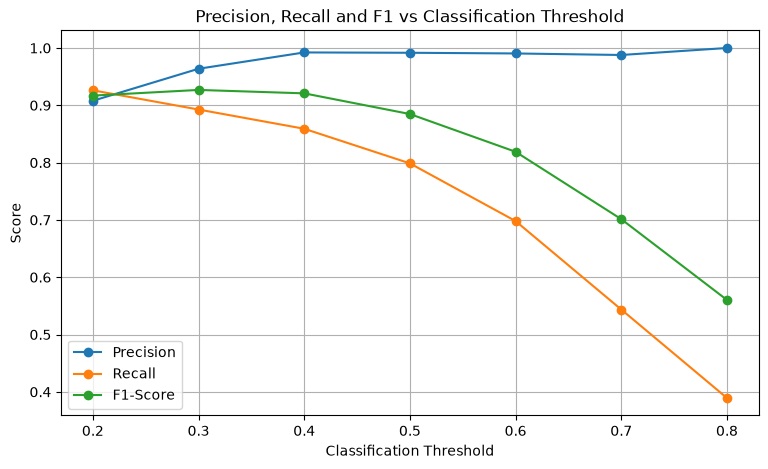

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs Classification Threshold")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1-Score"].idxmax()
]

print("Best tested threshold based on F1:")
print(f"Threshold: {best_threshold_row['Threshold']}")
print(f"Precision: {best_threshold_row['Precision']:.4f}")
print(f"Recall:    {best_threshold_row['Recall']:.4f}")
print(f"F1-Score:  {best_threshold_row['F1-Score']:.4f}")

Best tested threshold based on F1:
Threshold: 0.3
Precision: 0.9638
Recall:    0.8926
F1-Score:  0.9268


## Threshold Analysis Conclusion

The default 0.5 classification threshold is not optimal for this
evaluation dataset when F1-score is the primary metric.

Among the tested thresholds, 0.3 produced the highest F1-score:

- Precision: 0.9638
- Recall: 0.8926
- F1-score: 0.9268

Lowering the threshold from 0.5 to 0.3 substantially improves recall
while maintaining relatively high precision.

However, this threshold should not automatically be treated as the
production threshold. Threshold selection should depend on the actual
cost of false positives versus false negatives and should ideally be
validated on separate validation data.

## 11. Model Evaluation Summary

### Baseline Performance

The saved Logistic Regression classifier using unigram TF-IDF achieved:

- Accuracy: 97.22%
- Precision: 99.17%
- Recall: 79.87%
- F1-Score: 88.48%

### Error Profile

The test set contained:

- True Negatives: 965
- False Positives: 1
- False Negatives: 30
- True Positives: 119

The model therefore has an extremely low false-positive rate but misses
a significant portion of spam messages.

### False Negative Analysis

The missed spam messages showed several recurring patterns:

- Very short spam messages
- Phone-number-heavy messages
- Obfuscated SMS language
- Promotional and subscription messages
- Adult/dating spam
- Messages resembling ordinary conversations
- Service-style messages such as voicemail or delivery notifications
- Unusual or joke-like messages

These patterns suggest that unigram TF-IDF does not always capture enough
context to distinguish spam from legitimate conversational language.

### Confidence Analysis

Several false negatives received very low spam probabilities.

For example, some incorrectly classified spam messages received spam
probabilities below 0.10.

This indicates that some errors were not merely borderline decisions;
the model was confidently incorrect.

### Threshold Analysis

The default threshold of 0.5 produced:

- Precision: 99.17%
- Recall: 79.87%
- F1-Score: 88.48%

Among the tested thresholds, 0.3 produced the highest F1-score:

- Precision: 96.38%
- Recall: 89.26%
- F1-Score: 92.68%

This demonstrates that classification threshold selection can have a
substantial effect on the precision-recall trade-off.

The 0.3 threshold is treated as an evaluation finding rather than a
final production decision because threshold selection should consider
the relative cost of false positives and false negatives and should be
validated appropriately.

## 12. Improvement Hypotheses

Based on the error analysis, the following improvements are worth
investigating in future experiments.

### Hypothesis 1 — Character-level features

Character n-grams may help detect:

- obfuscated words
- unusual spelling
- shortened SMS language
- phone-number patterns
- fragmented promotional terms

### Hypothesis 2 — Better handling of numeric information

Many false negatives contain:

- phone numbers
- prices
- premium-rate numbers
- numeric codes

Feature engineering around numeric patterns may improve spam detection.

### Hypothesis 3 — Threshold optimization

The evaluation showed that reducing the threshold from 0.5 to 0.3
increased recall substantially while maintaining strong precision.

This should be validated using a proper validation procedure before
being adopted.

### Hypothesis 4 — Alternative feature representations

The earlier bigram experiment performed worse than the unigram baseline.

Therefore, simply adding word bigrams is not automatically an
improvement.

Future experiments should investigate other representations rather than
assuming that more features always produce better results.

### Hypothesis 5 — Error-driven preprocessing

The false negatives contain SMS-specific patterns such as:

- "u"
- "ur"
- "2"
- "4"
- abbreviated words
- phone numbers
- pricing formats

A future preprocessing experiment could investigate whether
normalizing these patterns improves generalization.

## 13. Final Evaluation Decision

The Logistic Regression model with unigram TF-IDF remains the selected
baseline model.

Its strongest characteristic is extremely high precision, with only
one false positive in the test set.

Its primary weakness is recall: 30 spam messages were incorrectly
classified as ham.

The error analysis indicates that many missed spam messages contain
SMS-specific language, numeric patterns, short messages, and wording
that resembles legitimate conversations.

Threshold analysis demonstrated that the default 0.5 threshold is not
necessarily optimal for F1-score. A threshold of 0.3 achieved the best
F1-score among the tested thresholds.

These findings provide concrete directions for future model
improvements.

## 14. Save Evaluation Results

The threshold comparison will be saved as a CSV artifact so that future
experiments can compare against these results.

In [22]:
threshold_df.to_csv(
    "../models/threshold_analysis.csv",
    index=False
)

print("Threshold analysis saved successfully.")

Threshold analysis saved successfully.


In [23]:
import os

print(os.listdir("../models"))

['.gitkeep', 'bigram_logistic_regression_model.pkl', 'bigram_tfidf_vectorizer.pkl', 'logistic_regression_model.pkl', 'logistic_tfidf_vectorizer.pkl', 'naive_bayes_model.pkl', 'tfidf_vectorizer.pkl', 'threshold_analysis.csv']
